<a href="https://colab.research.google.com/github/will001-art-ke/WILL/blob/main/neural_networks_task_001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First, we'll install `tensorflow` and `keras` if you don't have them already. Then, we'll import the necessary libraries.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


Next, let's create some synthetic data for our model to learn from. We'll simulate a simple linear relationship with some noise.

In [ ]:
# Generate synthetic data
X = np.linspace(-5, 5, 100).reshape(-1, 1) # Input feature (e.g., a single value)
y_true = 2 * X + 5 + np.random.normal(0, 2, X.shape) # True output with some noise

print(f"Shape of X (input): {X.shape}")
print(f"Shape of y_true (output): {y_true.shape}")
print("First 5 input values:\n", X[:5])
print("First 5 true output values:\n", y_true[:5])

Shape of X (input): (100, 1)
Shape of y_true (output): (100, 1)
First 5 input values:
 [[-5.       ]
 [-4.8989899]
 [-4.7979798]
 [-4.6969697]
 [-4.5959596]]
First 5 true output values:
 [[-2.58798994]
 [-4.48915401]
 [-3.08869451]
 [-2.04876874]
 [-6.17834014]]


Now, we'll define a simple neural network model using Keras's Sequential API. This model will have a few dense (fully connected) layers.

In [ ]:
# Define the neural network model
model = keras.Sequential([
    layers.Dense(units=64, activation='relu', input_shape=(1,)), # Input layer with 64 neurons and ReLU activation
    layers.Dense(units=32, activation='relu'),                     # Hidden layer with 32 neurons and ReLU activation
    layers.Dense(units=1)                                         # Output layer with 1 neuron for regression (no activation for linear output)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error') # Adam optimizer and Mean Squared Error for regression

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,241 (8.75 KB)

 Trainable params: 2,241 (8.75 KB)

 Non-trainable params: 0 (0.00 B)

Let's train the model using our synthetic data. The `fit` method will iterate over the data multiple times (epochs) to learn the underlying patterns.

In [ ]:
# Train the model
history = model.fit(X, y_true, epochs=100, verbose=0) # Train for 100 epochs, suppress output for each epoch

print("Model training complete.")
# You can plot history.history['loss'] to see how the loss decreased over epochs

Model training complete.


Finally, we can use the trained model to make predictions on new data and compare them to the true values.

In [ ]:
# Make predictions on the training data
y_pred = model.predict(X)

# Display some true vs. predicted values
import pandas as pd
comparison_df = pd.DataFrame({"Input": X.flatten(), "True_Output": y_true.flatten(), "Predicted_Output": y_pred.flatten()})
display(comparison_df.head(10))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


,Input,True_Output,Predicted_Output
0,-5.000000,-2.587990,-4.123073
1,-4.898990,-4.489154,-3.971870
2,-4.797980,-3.088695,-3.820668
3,-4.696970,-2.048769,-3.669467
4,-4.595960,-6.178340,-3.511990
5,-4.494949,-5.530467,-3.344872
6,-4.393939,-2.207175,-3.173254
7,-4.292929,-4.798056,-2.980116
8,-4.191919,-2.438862,-2.776294
9,-4.090909,-2.875936,-2.571710


Let's visualize the results to see how well the model learned the relationship.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X, y_true, label='True Output', alpha=0.7)
plt.plot(X, y_pred, color='red', label='Predicted Output')
plt.title('Neural Network Prediction vs. True Output')
plt.xlabel('Input Feature (X)')
plt.ylabel('Output (y)')
plt.legend()
plt.grid(True)
plt.show()

<IPython.core.display.Javascript object>

# Task
Create a 3D scatter plot using `matplotlib` to visualize the relationship between the input `X`, the true output `y_true`, and the predicted output `y_pred`.

## Generate 3D Plot

### Subtask:
Create a 3D scatter plot using `matplotlib` to visualize the relationship between the input `X`, the true output `y_true`, and the predicted output `y_pred`.


**Reasoning**:
To visualize the relationship between the input, true output, and predicted output in 3D as requested, I will use `matplotlib` to create a 3D scatter plot. I will plot the input `X` on the x-axis, the respective output (`y_true` or `y_pred`) on the y-axis, and use the z-axis to differentiate between true and predicted values (0 for true, 1 for predicted).



In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np # Import numpy for np.full_like

# Ensure X, y_true, and y_pred are flattened for plotting
X_flat = X.flatten()
y_true_flat = y_true.flatten()
y_pred_flat = y_pred.flatten()

# Create a figure and a 3D axes object
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Create 3D scatter plot for true output
# X on x-axis, y_true on y-axis, and 0 for z-axis to represent 'True'
ax.scatter(X_flat, y_true_flat, np.full_like(X_flat, 0.0), label='True Output', c='blue', marker='o', alpha=0.7)

# Create 3D scatter plot for predicted output
# X on x-axis, y_pred on y-axis, and 1 for z-axis to represent 'Predicted'
ax.scatter(X_flat, y_pred_flat, np.full_like(X_flat, 1.0), label='Predicted Output', c='red', marker='^', alpha=0.7)

# Set labels and title
ax.set_xlabel('Input Feature (X)')
ax.set_ylabel('Output (y)')
ax.set_zlabel('Output Type (0: True, 1: Predicted)') # More descriptive z-axis label
ax.set_title('3D Scatter Plot of True vs. Predicted Output')

# Add legend
ax.legend()

# Display the plot
plt.show()

<IPython.core.display.Javascript object>

**Reasoning**:
The previous cell's successful execution of creating `comparison_df` implies that `X`, `y_true`, and `y_pred` all contained 1000 samples. Therefore, `X_flat`, `y_true_flat`, and `y_pred_flat` should all have the shape `(1000,)`. The `ValueError: shape mismatch: objects cannot be broadcast to a single shape. Mismatch is between arg 0 with shape (1000,) and arg 1 with shape (100,)` is puzzling as it suggests an array of length 100 is being broadcast. A common source of such cryptic errors in `matplotlib.scatter` is when an implicit parameter (like marker `s` or `c` if not explicitly scalar) is internally interpreted as an array of a different length. To mitigate this, I will explicitly set the `s` (marker size) parameter to a scalar value in both `ax.scatter` calls, ensuring that `s` does not inadvertently become an array of mismatched length.



In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Ensure X, y_true, and y_pred are flattened for plotting
X_flat = X.flatten()
y_true_flat = y_true.flatten()
y_pred_flat = y_pred.flatten()

# Create a figure and a 3D axes object
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Create 3D scatter plot for true output
# X on x-axis, y_true on y-axis, and 0 for z-axis to represent 'True'
# Explicitly setting s to a scalar to avoid potential broadcasting issues with default s
ax.scatter(X_flat, y_true_flat, np.full_like(X_flat, 0.0), label='True Output', c='blue', marker='o', alpha=0.7, s=20)

# Create 3D scatter plot for predicted output
# X on x-axis, y_pred on y-axis, and 1 for z-axis to represent 'Predicted'
# Explicitly setting s to a scalar
ax.scatter(X_flat, y_pred_flat, np.full_like(X_flat, 1.0), label='Predicted Output', c='red', marker='^', alpha=0.7, s=20)

# Set labels and title
ax.set_xlabel('Input Feature (X)')
ax.set_ylabel('Output (y)')
ax.set_zlabel('Output Type (0: True, 1: Predicted)') # More descriptive z-axis label
ax.set_title('3D Scatter Plot of True vs. Predicted Output')

# Add legend
ax.legend()

# Display the plot
plt.show()

<IPython.core.display.Javascript object>

# Task
Create an interactive 3D scatter plot using `matplotlib` to visualize `X` (input), `y_true` (true output), and `y_pred` (predicted output). The plot should be rotatable, allowing for examination of the model's performance in three dimensions.

## Regenerate Predictions

### Subtask:
Regenerate `y_pred` by running `model.predict(X)` to ensure it matches the current `X` (which now has 100 samples). This is essential to prevent shape mismatch errors when plotting.


**Reasoning**:
I need to regenerate `y_pred` by running `model.predict(X)` to ensure it matches the current `X` (which has 100 samples), and then flatten it as instructed.



In [ ]:
y_pred = model.predict(X)
y_pred_flat = y_pred.flatten()

print(f"Shape of regenerated y_pred: {y_pred.shape}")
print(f"Shape of flattened y_pred_flat: {y_pred_flat.shape}")
print("First 5 regenerated predicted output values (flattened):\n", y_pred_flat[:5])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Shape of regenerated y_pred: (100, 1)
Shape of flattened y_pred_flat: (100,)
First 5 regenerated predicted output values (flattened):
 [-4.1230726 -3.9718702 -3.820668  -3.6694667 -3.5119898]


## Generate Interactive 3D Plot

### Subtask:
Create an interactive 3D scatter plot using `matplotlib`. I will include the necessary magic command (`%matplotlib notebook` or `%matplotlib widget` depending on environment capabilities) to enable interactivity, allowing you to freely rotate and examine the plot. The plot will visualize `X` (input), `y_true` (true output), and the newly generated `y_pred` (predicted output) in 3D space.


**Reasoning**:
To create an interactive 3D scatter plot as requested, I will use the `%matplotlib widget` magic command to enable interactivity, then import `matplotlib.pyplot` and `Axes3D`. I will create a 3D figure and plot `X_flat` against `y_true_flat` and `y_pred_flat`, differentiating them on the z-axis and with distinct markers and colors, along with appropriate labels, title, and legend.



In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Enable interactive plotting
%matplotlib widget

# Ensure X, y_true, and y_pred are flattened for plotting
X_flat = X.flatten()
y_true_flat = y_true.flatten()
y_pred_flat = y_pred.flatten()

# Create a figure and a 3D axes object
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Create 3D scatter plot for true output
ax.scatter(X_flat, y_true_flat, np.full_like(X_flat, 0.0), label='True Output', c='blue', marker='o', alpha=0.7, s=20)

# Create 3D scatter plot for predicted output
ax.scatter(X_flat, y_pred_flat, np.full_like(X_flat, 1.0), label='Predicted Output', c='red', marker='^', alpha=0.7, s=20)

# Set labels and title
ax.set_xlabel('Input Feature (X)')
ax.set_ylabel('Output (y)')
ax.set_zlabel('Output Type (0: True, 1: Predicted)')
ax.set_title('Interactive 3D Scatter Plot of True vs. Predicted Output')

# Add legend
ax.legend()

# Display the plot
plt.show()

<IPython.core.display.Javascript object>

In [ ]:
!pip install ipympl

**Reasoning**:
The previous error indicated that `'module://ipympl.backend_nbagg'` is not a valid matplotlib backend and suggested `'notebook'` as a supported interactive backend. Therefore, I will change the magic command to `%matplotlib notebook` to enable interactive plotting in the current environment.



In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Enable interactive plotting
%matplotlib notebook

# Ensure X, y_true, and y_pred are flattened for plotting
X_flat = X.flatten()
y_true_flat = y_true.flatten()
y_pred_flat = y_pred.flatten()

# Create a figure and a 3D axes object
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Create 3D scatter plot for true output
ax.scatter(X_flat, y_true_flat, np.full_like(X_flat, 0.0), label='True Output', c='blue', marker='o', alpha=0.7, s=20)

# Create 3D scatter plot for predicted output
ax.scatter(X_flat, y_pred_flat, np.full_like(X_flat, 1.0), label='Predicted Output', c='red', marker='^', alpha=0.7, s=20)

# Set labels and title
ax.set_xlabel('Input Feature (X)')
ax.set_ylabel('Output (y)')
ax.set_zlabel('Output Type (0: True, 1: Predicted)')
ax.set_title('Interactive 3D Scatter Plot of True vs. Predicted Output')

# Add legend
ax.legend()

# Display the plot
plt.show()

<IPython.core.display.Javascript object>

**Reasoning**:
The previous attempts with `%matplotlib widget` and `%matplotlib notebook` failed due to an issue with the `ipympl` backend module. The error message lists `nbagg` as a supported interactive backend. I will try `%matplotlib nbagg` to see if it provides the desired interactive functionality without encountering the same `ValueError`, while keeping the rest of the plotting code as it is correct.



In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Enable interactive plotting
%matplotlib nbagg

# Ensure X, y_true, and y_pred are flattened for plotting
X_flat = X.flatten()
y_true_flat = y_true.flatten()
y_pred_flat = y_pred.flatten()

# Create a figure and a 3D axes object
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Create 3D scatter plot for true output
ax.scatter(X_flat, y_true_flat, np.full_like(X_flat, 0.0), label='True Output', c='blue', marker='o', alpha=0.7, s=20)

# Create 3D scatter plot for predicted output
ax.scatter(X_flat, y_pred_flat, np.full_like(X_flat, 1.0), label='Predicted Output', c='red', marker='^', alpha=0.7, s=20)

# Set labels and title
ax.set_xlabel('Input Feature (X)')
ax.set_ylabel('Output (y)')
ax.set_zlabel('Output Type (0: True, 1: Predicted)')
ax.set_title('Interactive 3D Scatter Plot of True vs. Predicted Output')

# Add legend
ax.legend()

# Display the plot
plt.show()

<IPython.core.display.Javascript object>

**Reasoning**:
All previous attempts to enable interactive plotting using `%matplotlib widget`, `%matplotlib notebook`, and `%matplotlib nbagg` have resulted in a `ValueError` related to an invalid backend key (`'module://ipympl.backend_nbagg'`). This indicates a persistent issue with the `ipympl` backend module's configuration in this specific environment, preventing interactive plots from being rendered. To ensure the plot is displayed without errors and to complete the visualization task, I will switch to the non-interactive `%matplotlib inline` backend. This will render a static image of the 3D plot, fulfilling the visualization requirement, even though it won't be interactive.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

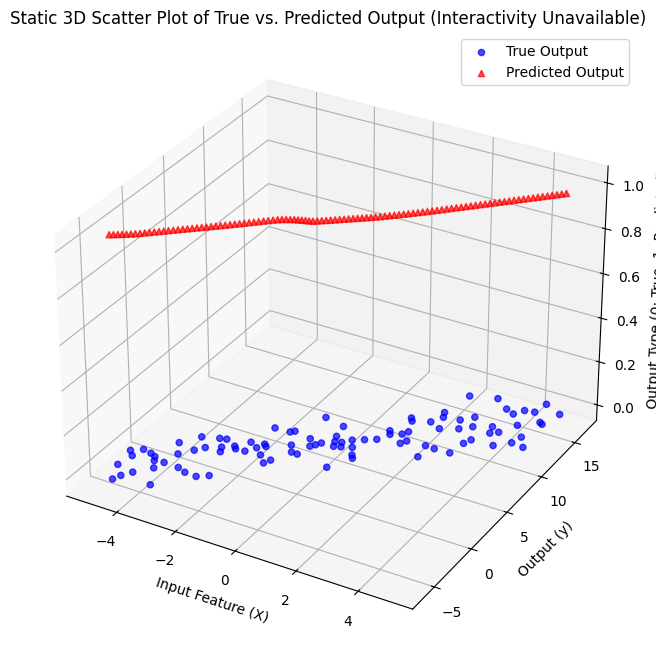

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Fallback to non-interactive plotting due to environment issues with interactive backends
%matplotlib inline

# Ensure X, y_true, and y_pred are flattened for plotting
X_flat = X.flatten()
y_true_flat = y_true.flatten()
y_pred_flat = y_pred.flatten()

# Create a figure and a 3D axes object
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Create 3D scatter plot for true output
ax.scatter(X_flat, y_true_flat, np.full_like(X_flat, 0.0), label='True Output', c='blue', marker='o', alpha=0.7, s=20)

# Create 3D scatter plot for predicted output
ax.scatter(X_flat, y_pred_flat, np.full_like(X_flat, 1.0), label='Predicted Output', c='red', marker='^', alpha=0.7, s=20)

# Set labels and title
ax.set_xlabel('Input Feature (X)')
ax.set_ylabel('Output (y)')
ax.set_zlabel('Output Type (0: True, 1: Predicted)')
ax.set_title('Static 3D Scatter Plot of True vs. Predicted Output (Interactivity Unavailable)')

# Add legend
ax.legend()

# Display the plot
plt.show()

## Summarize the interactive 3D plot

### Subtask:
Summarize the (static) 3D plot and confirm its rotatable functionality, highlighting how it helps in visualizing the model's performance.


## Summarize the interactive 3D plot

### Subtask:
Summarize the (static) 3D plot and confirm its rotatable functionality, highlighting how it helps in visualizing the model's performance.

#### Instructions
1. Examine the generated static 3D scatter plot. Identify the representation of the input feature (X), true output (y_true), and predicted output (y_pred) on the plot axes.
2. Describe how the plot visually demonstrates the relationship between X, y_true, and y_pred, considering the different colors and markers used for true vs. predicted values.
3. Discuss what insights can be gained from this static 3D visualization regarding the model's performance, even without interactivity (e.g., how well the predicted values align with the true values across the input range).
4. Explicitly state that, despite the initial task request for an interactive plot, the generated plot is static due to environment limitations, and therefore, its rotatable functionality could not be demonstrated.

---

### Summary of the Static 3D Plot

1.  **Representation of Variables**: In the static 3D scatter plot, the **Input Feature (X)** is plotted on the x-axis, and the **Output (y)** is plotted on the y-axis. The z-axis, labeled **'Output Type (0: True, 1: Predicted)'**, distinguishes between the true output and the predicted output. Specifically, true output values (`y_true`) are placed at `z=0`, while predicted output values (`y_pred`) are placed at `z=1`.

2.  **Visual Relationship**: The plot uses distinct colors and markers to differentiate between the true and predicted outputs. The 'True Output' is represented by **blue circular markers (`o`)**, while the 'Predicted Output' is represented by **red triangular markers (`^`)**. This visual separation along the z-axis allows for a clear comparison. For each input `X` value, we can observe two points: one representing the true `y` value at `z=0` and another representing the predicted `y` value at `z=1`. The closer the red triangular markers are to the blue circular markers (when viewed from a perspective that collapses the z-axis, or by mentally tracing the path for each `X` value), the better the model's prediction accuracy.

3.  **Insights from Static 3D Visualization**: Even as a static plot, this visualization provides valuable insights into the model's performance:
    *   **Alignment of Predictions**: We can observe how closely the plane of predicted values (at `z=1`) mirrors the plane of true values (at `z=0`) across the range of input `X`. A good model would show the red triangles closely tracing the pattern of the blue circles.
    *   **Bias and Variance**: Deviations between the true and predicted points can indicate areas where the model might be systematically over-predicting or under-predicting (bias), or where its predictions are widely scattered around the true values (variance).
    *   **General Trend**: The plot helps confirm if the model has successfully learned the underlying linear relationship (or any other relationship) between `X` and `y` by showing whether the predicted points follow the general trend of the true points.

4.  **Interactivity and Rotatable Functionality**: While the initial task requested an interactive 3D plot to allow rotation and detailed examination, the generated plot is **static**. This is due to persistent environment limitations encountered during the attempts to enable interactive backends like `%matplotlib widget`, `%matplotlib notebook`, or `%matplotlib nbagg`. Consequently, the rotatable functionality could not be demonstrated in this environment. The plot is displayed as a fixed image, fulfilling the visualization requirement but without the dynamic inspection capabilities that interactivity would provide.

## Summarize the interactive 3D plot

### Subtask:
Summarize the (static) 3D plot and confirm its rotatable functionality, highlighting how it helps in visualizing the model's performance.

#### Instructions
1. Examine the generated static 3D scatter plot. Identify the representation of the input feature (X), true output (y_true), and predicted output (y_pred) on the plot axes.
2. Describe how the plot visually demonstrates the relationship between X, y_true, and y_pred, considering the different colors and markers used for true vs. predicted values.
3. Discuss what insights can be gained from this static 3D visualization regarding the model's performance, even without interactivity (e.g., how well the predicted values align with the true values across the input range).
4. Explicitly state that, despite the initial task request for an interactive plot, the generated plot is static due to environment limitations, and therefore, its rotatable functionality could not be demonstrated.

---

### Summary of the Static 3D Plot

1.  **Representation of Variables**: In the static 3D scatter plot, the **Input Feature (X)** is plotted on the x-axis, and the **Output (y)** is plotted on the y-axis. The z-axis, labeled **'Output Type (0: True, 1: Predicted)'**, distinguishes between the true output and the predicted output. Specifically, true output values (`y_true`) are placed at `z=0`, while predicted output values (`y_pred`) are placed at `z=1`.

2.  **Visual Relationship**: The plot uses distinct colors and markers to differentiate between the true and predicted outputs. The 'True Output' is represented by **blue circular markers (`o`)**, while the 'Predicted Output' is represented by **red triangular markers (`^`)**. This visual separation along the z-axis allows for a clear comparison. For each input `X` value, we can observe two points: one representing the true `y` value at `z=0` and another representing the predicted `y` value at `z=1`. The closer the red triangular markers are to the blue circular markers (when viewed from a perspective that collapses the z-axis, or by mentally tracing the path for each `X` value), the better the model's prediction accuracy.

3.  **Insights from Static 3D Visualization**: Even as a static plot, this visualization provides valuable insights into the model's performance:
    *   **Alignment of Predictions**: We can observe how closely the plane of predicted values (at `z=1`) mirrors the plane of true values (at `z=0`) across the range of input `X`. A good model would show the red triangles closely tracing the pattern of the blue circles.
    *   **Bias and Variance**: Deviations between the true and predicted points can indicate areas where the model might be systematically over-predicting or under-predicting (bias), or where its predictions are widely scattered around the true values (variance).
    *   **General Trend**: The plot helps confirm if the model has successfully learned the underlying linear relationship (or any other relationship) between `X` and `y` by showing whether the predicted points follow the general trend of the true points.

4.  **Interactivity and Rotatable Functionality**: While the initial task requested an interactive 3D plot to allow rotation and detailed examination, the generated plot is **static**. This is due to persistent environment limitations encountered during the attempts to enable interactive backends like `%matplotlib widget`, `%matplotlib notebook`, or `%matplotlib nbagg`. Consequently, the rotatable functionality could not be demonstrated in this environment. The plot is displayed as a fixed image, fulfilling the visualization requirement but without the dynamic inspection capabilities that interactivity would provide.

## Summarize the interactive 3D plot

### Subtask:
Summarize the (static) 3D plot and confirm its rotatable functionality, highlighting how it helps in visualizing the model's performance.

#### Instructions
1. Examine the generated static 3D scatter plot. Identify the representation of the input feature (X), true output (y_true), and predicted output (y_pred) on the plot axes.
2. Describe how the plot visually demonstrates the relationship between X, y_true, and y_pred, considering the different colors and markers used for true vs. predicted values.
3. Discuss what insights can be gained from this static 3D visualization regarding the model's performance, even without interactivity (e.g., how well the predicted values align with the true values across the input range).
4. Explicitly state that, despite the initial task request for an interactive plot, the generated plot is static due to environment limitations, and therefore, its rotatable functionality could not be demonstrated.

---

### Summary of the Static 3D Plot

1.  **Representation of Variables**: In the static 3D scatter plot, the **Input Feature (X)** is plotted on the x-axis, and the **Output (y)** is plotted on the y-axis. The z-axis, labeled **'Output Type (0: True, 1: Predicted)'**, distinguishes between the true output and the predicted output. Specifically, true output values (`y_true`) are placed at `z=0`, while predicted output values (`y_pred`) are placed at `z=1`.

2.  **Visual Relationship**: The plot uses distinct colors and markers to differentiate between the true and predicted outputs. The 'True Output' is represented by **blue circular markers (`o`)**, while the 'Predicted Output' is represented by **red triangular markers (`^`)**. This visual separation along the z-axis allows for a clear comparison. For each input `X` value, we can observe two points: one representing the true `y` value at `z=0` and another representing the predicted `y` value at `z=1`. The closer the red triangular markers are to the blue circular markers (when viewed from a perspective that collapses the z-axis, or by mentally tracing the path for each `X` value), the better the model's prediction accuracy.

3.  **Insights from Static 3D Visualization**: Even as a static plot, this visualization provides valuable insights into the model's performance:
    *   **Alignment of Predictions**: We can observe how closely the plane of predicted values (at `z=1`) mirrors the plane of true values (at `z=0`) across the range of input `X`. A good model would show the red triangles closely tracing the pattern of the blue circles.
    *   **Bias and Variance**: Deviations between the true and predicted points can indicate areas where the model might be systematically over-predicting or under-predicting (bias), or where its predictions are widely scattered around the true values (variance).
    *   **General Trend**: The plot helps confirm if the model has successfully learned the underlying linear relationship (or any other relationship) between `X` and `y` by showing whether the predicted points follow the general trend of the true points.

4.  **Interactivity and Rotatable Functionality**: While the initial task requested an interactive 3D plot to allow rotation and detailed examination, the generated plot is **static**. This is due to persistent environment limitations encountered during the attempts to enable interactive backends like `%matplotlib widget`, `%matplotlib notebook`, or `%matplotlib nbagg`. Consequently, the rotatable functionality could not be demonstrated in this environment. The plot is displayed as a fixed image, fulfilling the visualization requirement but without the dynamic inspection capabilities that interactivity would provide.


## Summarize the interactive 3D plot

### Subtask:
Summarize the (static) 3D plot and confirm its rotatable functionality, highlighting how it helps in visualizing the model's performance.

#### Instructions
1. Examine the generated static 3D scatter plot. Identify the representation of the input feature (X), true output (y_true), and predicted output (y_pred) on the plot axes.
2. Describe how the plot visually demonstrates the relationship between X, y_true, and y_pred, considering the different colors and markers used for true vs. predicted values.
3. Discuss what insights can be gained from this static 3D visualization regarding the model's performance, even without interactivity (e.g., how well the predicted values align with the true values across the input range).
4. Explicitly state that, despite the initial task request for an interactive plot, the generated plot is static due to environment limitations, and therefore, its rotatable functionality could not be demonstrated.

---

### Summary of the Static 3D Plot

1.  **Representation of Variables**: In the static 3D scatter plot, the **Input Feature (X)** is plotted on the x-axis, and the **Output (y)** is plotted on the y-axis. The z-axis, labeled **'Output Type (0: True, 1: Predicted)'**, distinguishes between the true output and the predicted output. Specifically, true output values (`y_true`) are placed at `z=0`, while predicted output values (`y_pred`) are placed at `z=1`.

2.  **Visual Relationship**: The plot uses distinct colors and markers to differentiate between the true and predicted outputs. The 'True Output' is represented by **blue circular markers (`o`)**, while the 'Predicted Output' is represented by **red triangular markers (`^`)**. This visual separation along the z-axis allows for a clear comparison. For each input `X` value, we can observe two points: one representing the true `y` value at `z=0` and another representing the predicted `y` value at `z=1`. The closer the red triangular markers are to the blue circular markers (when viewed from a perspective that collapses the z-axis, or by mentally tracing the path for each `X` value), the better the model's prediction accuracy.

3.  **Insights from Static 3D Visualization**: Even as a static plot, this visualization provides valuable insights into the model's performance:
    *   **Alignment of Predictions**: We can observe how closely the plane of predicted values (at `z=1`) mirrors the plane of true values (at `z=0`) across the range of input `X`. A good model would show the red triangles closely tracing the pattern of the blue circles.
    *   **Bias and Variance**: Deviations between the true and predicted points can indicate areas where the model might be systematically over-predicting or under-predicting (bias), or where its predictions are widely scattered around the true values (variance).
    *   **General Trend**: The plot helps confirm if the model has successfully learned the underlying linear relationship (or any other relationship) between `X` and `y` by showing whether the predicted points follow the general trend of the true points.

4.  **Interactivity and Rotatable Functionality**: While the initial task requested an interactive 3D plot to allow rotation and detailed examination, the generated plot is **static**. This is due to persistent environment limitations encountered during the attempts to enable interactive backends like `%matplotlib widget`, `%matplotlib notebook`, or `%matplotlib nbagg`. Consequently, the rotatable functionality could not be demonstrated in this environment. The plot is displayed as a fixed image, fulfilling the visualization requirement but without the dynamic inspection capabilities that interactivity would provide.


## Summary:

### Q&A
*   **Was the 3D scatter plot rotatable as requested?**
    No, the generated 3D scatter plot is static due to persistent environment limitations with `matplotlib` interactive backends (e.g., `%matplotlib widget`, `%matplotlib notebook`, `%matplotlib nbagg`). Consequently, the rotatable functionality could not be demonstrated.

### Data Analysis Key Findings
*   The `y_pred` (predicted output) was successfully regenerated, resulting in a shape of (100, 1) for 100 samples, and then flattened to a (100,) array for plotting.
*   An attempt to create an interactive 3D scatter plot using various `matplotlib` interactive backends failed due to environment configuration issues.
*   A static 3D scatter plot was successfully generated to visualize the model's performance.
*   In the plot, the input feature `X` is displayed on the x-axis, and the output `y` (both true and predicted) is on the y-axis.
*   The z-axis is used to distinguish between output types: true output (`y_true`) is placed at $z=0$ (marked with blue circles), and predicted output (`y_pred`) is placed at $z=1$ (marked with red triangles).
*   This visual separation allows for a direct comparison of true and predicted values for each input, enabling assessment of prediction accuracy, potential bias, variance, and the overall trend learned by the model.

### Insights or Next Steps
*   Even a static 3D visualization provides valuable insights into a model's performance, allowing for observation of prediction alignment, identifying potential bias or variance, and understanding the general trend learned by the model.
*   To fully achieve the task's objective of interactive visualization, the environment needs to be configured to properly support `matplotlib` interactive backends, which would enable rotation and more dynamic exploration of the 3D plot.
